# Wav2Vec2 Gating Network Notebook

This notebook builds and validates a learnable temporal gating network for PD vs HC classification.

Execution style: run cells sequentially from top to bottom.

## 1. Environment Setup and Reproducibility

In [1]:
import subprocess
import sys

subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "torch",
    "torchaudio",
    "transformers",
    "datasets",
    "evaluate",
    "scikit-learn",
    "matplotlib",
    "pandas",
    "numpy",
    "soundfile",
], check=True)

print("Dependencies installed.")

Dependencies installed.


In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from transformers import Wav2Vec2Model, Wav2Vec2Processor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

Device: cpu
torch: 2.10.0+cu128
torchaudio: 2.10.0+cu128
numpy: 2.4.2
pandas: 3.0.1


## 2. Project Configuration and Hyperparameters

In [3]:
CFG = {
    "checkpoint": "facebook/wav2vec2-base",
    "sampling_rate": 16000,
    "max_audio_seconds": 10,
    "batch_size": 12,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 3,
    "num_folds": 5,
    "freeze_backbone": True,
    "smoke_test_samples": 60,
}

ROOT = Path.cwd().resolve().parent
SEG_ROOT = ROOT / "segments"
META_PATH = Path.cwd() / "metadata.csv"
OUT_DIR = Path.cwd() / "results" / "gating_network"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("SEG_ROOT:", SEG_ROOT)
print("META_PATH:", META_PATH)
print("OUT_DIR:", OUT_DIR)
print(CFG)

ROOT: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation
SEG_ROOT: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/segments
META_PATH: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/metadata.csv
OUT_DIR: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/results/gating_network
{'checkpoint': 'facebook/wav2vec2-base', 'sampling_rate': 16000, 'max_audio_seconds': 10, 'batch_size': 12, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'epochs': 3, 'num_folds': 5, 'freeze_backbone': True, 'smoke_test_samples': 60}


## 3. Load Wav2Vec2 Processor, Backbone, and Audio Data

In [4]:
processor = Wav2Vec2Processor.from_pretrained(CFG["checkpoint"])
backbone = Wav2Vec2Model.from_pretrained(CFG["checkpoint"]).to(DEVICE)
backbone.eval()

if CFG["freeze_backbone"]:
    for p in backbone.parameters():
        p.requires_grad = False

print("Loaded checkpoint:", CFG["checkpoint"])
print("Backbone frozen:", CFG["freeze_backbone"])

meta = pd.read_csv(META_PATH)
meta = meta[meta["segment"].isin(["early", "middle", "late"])].copy()

# Keep only subjects with all 3 segments and keep a small smoke subset.
counts = meta.groupby(["original_stem", "class"]) ["segment"].nunique().reset_index()
full_subjects = counts[counts["segment"] == 3][["original_stem", "class"]]
full_meta = meta.merge(full_subjects, on=["original_stem", "class"], how="inner")
subject_rows = full_meta[["original_stem", "class"]].drop_duplicates().sample(
    n=min(CFG["smoke_test_samples"], len(full_subjects)),
    random_state=SEED,
)
full_meta = full_meta.merge(subject_rows, on=["original_stem", "class"], how="inner")

print("Subjects selected:", subject_rows.shape[0])
print("Rows selected:", len(full_meta))
print(full_meta[["class", "segment"]].value_counts().sort_index())

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: facebook/wav2vec2-base
Backbone frozen: True
Subjects selected: 60
Rows selected: 180
class  segment
HC     early      48
       late       48
       middle     48
PD     early      12
       late       12
       middle     12
Name: count, dtype: int64


## 4. Preprocess Audio and Build Data Collator

In [8]:
def load_audio_as_16k_tensor(file_path: str, target_sr: int = 16000):
    wav, sr = torchaudio.load(file_path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    wav = wav.squeeze(0)
    max_samples = int(CFG["max_audio_seconds"] * target_sr)
    if wav.numel() > max_samples:
        wav = wav[:max_samples]
    return wav

records = []
for (stem, cls), grp in full_meta.groupby(["original_stem", "class"]):
    seg_map = {r.segment: r for r in grp.itertuples(index=False)}
    if not all(k in seg_map for k in ["early", "middle", "late"]):
        continue
    try:
        p_early = SEG_ROOT / cls / "early" / seg_map["early"].filename
        p_middle = SEG_ROOT / cls / "middle" / seg_map["middle"].filename
        p_late = SEG_ROOT / cls / "late" / seg_map["late"].filename
        row = {
            "original_stem": stem,
            "label": 1 if cls == "PD" else 0,
            "audio_early": load_audio_as_16k_tensor(str(p_early)).numpy(),
            "audio_middle": load_audio_as_16k_tensor(str(p_middle)).numpy(),
            "audio_late": load_audio_as_16k_tensor(str(p_late)).numpy(),
        }
        records.append(row)
    except (FileNotFoundError, RuntimeError):
        continue

data = Dataset.from_list(records)
print("Prepared subject-level dataset:", len(data))
print("Label counts:", pd.Series(data["label"]).value_counts().to_dict())

class SubjectAudioCollator:
    def __init__(self, processor, sampling_rate=16000):
        self.processor = processor
        self.sampling_rate = sampling_rate

    def _pad(self, waves):
        out = self.processor(
            waves,
            sampling_rate=self.sampling_rate,
            return_tensors="pt",
            padding=True,
            return_attention_mask=True,
        )
        input_values = out.input_values
        attention_mask = out.get("attention_mask")
        if attention_mask is None:
            attention_mask = torch.ones_like(input_values, dtype=torch.long)
        return input_values, attention_mask

    def __call__(self, examples):
        early = [ex["audio_early"] for ex in examples]
        mid = [ex["audio_middle"] for ex in examples]
        late = [ex["audio_late"] for ex in examples]
        e_x, e_m = self._pad(early)
        m_x, m_m = self._pad(mid)
        l_x, l_m = self._pad(late)
        y = torch.tensor([ex["label"] for ex in examples], dtype=torch.long)
        return {
            "early_input_values": e_x,
            "early_attention_mask": e_m,
            "middle_input_values": m_x,
            "middle_attention_mask": m_m,
            "late_input_values": l_x,
            "late_attention_mask": l_m,
            "labels": y,
        }

collator = SubjectAudioCollator(processor, sampling_rate=CFG["sampling_rate"])
print("Collator ready.")

Prepared subject-level dataset: 60
Label counts: {0: 48, 1: 12}
Collator ready.


## 5. Implement the Gating Network Module

In [6]:
class TemporalGating(nn.Module):
    def __init__(self, feature_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, f_early, f_middle, f_late):
        x = torch.cat([f_early, f_middle, f_late], dim=-1)
        logits = self.mlp(x)
        gates = torch.softmax(logits, dim=-1)
        f_gated = (
            gates[:, 0:1] * f_early
            + gates[:, 1:2] * f_middle
            + gates[:, 2:3] * f_late
        )
        return f_gated, gates

# Unit sanity check
B, D = 4, backbone.config.hidden_size
gate_mod = TemporalGating(feature_dim=D)
fe = torch.randn(B, D)
fm = torch.randn(B, D)
fl = torch.randn(B, D)
fused, gs = gate_mod(fe, fm, fl)
assert fused.shape == (B, D)
assert gs.shape == (B, 3)
assert torch.allclose(gs.sum(dim=-1), torch.ones(B), atol=1e-5)
print("TemporalGating sanity check passed.")

TemporalGating sanity check passed.


## 6. Inject Gating into Wav2Vec2 Hidden States

In [9]:
from torch.utils.data import DataLoader

class Wav2Vec2TemporalGatedClassifier(nn.Module):
    def __init__(self, backbone: Wav2Vec2Model, feature_dim: int, num_labels: int = 2):
        super().__init__()
        self.backbone = backbone
        self.gating = TemporalGating(feature_dim)
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels),
        )

    def encode_segment(self, input_values, attention_mask):
        out = self.backbone(input_values=input_values, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        pooled = hidden.mean(dim=1)
        return pooled

    def forward(self, batch, return_gates=False):
        f_e = self.encode_segment(batch["early_input_values"], batch["early_attention_mask"])
        f_m = self.encode_segment(batch["middle_input_values"], batch["middle_attention_mask"])
        f_l = self.encode_segment(batch["late_input_values"], batch["late_attention_mask"])

        f_gated, gates = self.gating(f_e, f_m, f_l)
        delta = f_l - f_e
        fused = torch.cat([f_gated, delta], dim=-1)
        logits = self.classifier(fused)

        assert logits.ndim == 2 and logits.shape[1] == 2
        assert gates.ndim == 2 and gates.shape[1] == 3

        if return_gates:
            return logits, gates
        return logits

# quick shape check
sample_loader = DataLoader(data.select(range(min(4, len(data)))), batch_size=2, collate_fn=collator)
sample_batch = next(iter(sample_loader))
sample_batch = {k: v.to(DEVICE) for k, v in sample_batch.items()}
model_check = Wav2Vec2TemporalGatedClassifier(backbone, backbone.config.hidden_size).to(DEVICE)
with torch.no_grad():
    lg, gt = model_check(sample_batch, return_gates=True)
print("Logits shape:", tuple(lg.shape), "Gates shape:", tuple(gt.shape))

Logits shape: (2, 2) Gates shape: (2, 3)


## 7. Define Loss, Optimizer, and Training Step

In [10]:
def make_optimizer(model):
    return torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=CFG["learning_rate"],
        weight_decay=CFG["weight_decay"],
    )

criterion = nn.CrossEntropyLoss()

def train_step(model, batch, optimizer):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    logits, gates = model(batch, return_gates=True)
    loss = criterion(logits, batch["labels"])

    if not torch.isfinite(loss):
        raise ValueError("Non-finite loss encountered.")

    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    with torch.no_grad():
        pred = logits.argmax(dim=-1)
        acc = (pred == batch["labels"]).float().mean().item()
        gate_stats = gates.mean(dim=0).detach().cpu().numpy()

    return {
        "loss": float(loss.item()),
        "acc": float(acc),
        "grad_norm": float(grad_norm),
        "gate_stats": gate_stats,
    }

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    ys, probs, preds = [], [], []
    gate_means = []
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits, gates = model(batch, return_gates=True)
        p = torch.softmax(logits, dim=-1)[:, 1]
        ys.extend(batch["labels"].cpu().tolist())
        probs.extend(p.cpu().tolist())
        preds.extend(logits.argmax(dim=-1).cpu().tolist())
        gate_means.append(gates.mean(dim=0).cpu().numpy())

    y = np.array(ys)
    p = np.array(probs)
    yhat = np.array(preds)
    metrics = {
        "acc": accuracy_score(y, yhat),
        "f1": f1_score(y, yhat),
        "auc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else float("nan"),
        "gate_mean": np.mean(gate_means, axis=0) if gate_means else np.zeros(3),
    }
    return metrics

## 8. Run Cell-by-Cell Training with Sanity Checks

In [11]:
labels = np.array(data["label"])
indices = np.arange(len(data))

class_counts = np.bincount(labels)
min_class_count = int(class_counts.min()) if len(class_counts) > 1 else 0
n_splits = min(CFG["num_folds"], min_class_count)
if n_splits < 2:
    raise ValueError("Need at least 2 samples per class for cross-validation.")

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

fold_results = []
gate_history = []

for fold_id, (tr_idx, va_idx) in enumerate(skf.split(indices, labels), start=1):
    train_ds = data.select(tr_idx.tolist())
    val_ds = data.select(va_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, collate_fn=collator)
    val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, collate_fn=collator)

    fold_model = Wav2Vec2TemporalGatedClassifier(backbone, backbone.config.hidden_size).to(DEVICE)
    optimizer = make_optimizer(fold_model)

    print(f"\nFold {fold_id} | train={len(train_ds)} val={len(val_ds)}")

    for epoch in range(1, CFG["epochs"] + 1):
        batch_stats = []
        for batch in train_loader:
            if batch["labels"].numel() == 0:
                raise ValueError("Empty batch found.")
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = train_step(fold_model, batch, optimizer)
            if not np.isfinite(out["loss"]):
                raise ValueError("NaN/Inf in training loss.")
            batch_stats.append(out)

        ep_loss = float(np.mean([x["loss"] for x in batch_stats]))
        ep_acc = float(np.mean([x["acc"] for x in batch_stats]))
        ep_grad = float(np.mean([x["grad_norm"] for x in batch_stats]))
        ep_gate = np.mean([x["gate_stats"] for x in batch_stats], axis=0)

        val_metrics = eval_epoch(fold_model, val_loader)
        print(
            f"Epoch {epoch:02d} | train_loss={ep_loss:.4f} train_acc={ep_acc:.4f} "
            f"grad_norm={ep_grad:.3f} | val_acc={val_metrics['acc']:.4f} "
            f"val_f1={val_metrics['f1']:.4f} val_auc={val_metrics['auc']:.4f} | "
            f"gates(e,m,l)={ep_gate.round(3)}"
        )

    fold_results.append(val_metrics)
    gate_history.append(val_metrics["gate_mean"])

summary = pd.DataFrame([
    {
        "fold": i + 1,
        "acc": r["acc"],
        "f1": r["f1"],
        "auc": r["auc"],
        "gate_early": r["gate_mean"][0],
        "gate_middle": r["gate_mean"][1],
        "gate_late": r["gate_mean"][2],
    }
    for i, r in enumerate(fold_results)
])

print("\nCross-validation summary")
display(summary)
print("Mean metrics:")
print(summary[["acc", "f1", "auc"]].mean(numeric_only=True))


Fold 1 | train=48 val=12
Epoch 01 | train_loss=0.5706 train_acc=0.8125 grad_norm=0.950 | val_acc=0.8333 val_f1=0.0000 val_auc=0.0500 | gates(e,m,l)=[0.211 0.577 0.212]
Epoch 02 | train_loss=0.4559 train_acc=0.7917 grad_norm=0.698 | val_acc=0.8333 val_f1=0.0000 val_auc=0.3000 | gates(e,m,l)=[0.198 0.411 0.39 ]
Epoch 03 | train_loss=0.3971 train_acc=0.8125 grad_norm=0.786 | val_acc=0.8333 val_f1=0.0000 val_auc=0.5000 | gates(e,m,l)=[0.371 0.212 0.417]

Fold 2 | train=48 val=12
Epoch 01 | train_loss=0.5711 train_acc=0.7500 grad_norm=1.002 | val_acc=0.8333 val_f1=0.0000 val_auc=0.5000 | gates(e,m,l)=[0.188 0.538 0.274]
Epoch 02 | train_loss=0.4745 train_acc=0.7917 grad_norm=0.960 | val_acc=0.8333 val_f1=0.0000 val_auc=0.4500 | gates(e,m,l)=[0.171 0.427 0.403]
Epoch 03 | train_loss=0.3832 train_acc=0.8125 grad_norm=0.663 | val_acc=0.7500 val_f1=0.0000 val_auc=0.4500 | gates(e,m,l)=[0.244 0.216 0.539]

Fold 3 | train=48 val=12
Epoch 01 | train_loss=0.5770 train_acc=0.6667 grad_norm=0.943 | 

,fold,acc,f1,auc,gate_early,gate_middle,gate_late
0,1,0.833333,0.0,0.500000,0.471719,0.175801,0.352481
1,2,0.750000,0.0,0.450000,0.183449,0.153442,0.663109
2,3,0.833333,0.0,0.400000,0.373685,0.123767,0.502548
3,4,0.750000,0.0,0.370370,0.080818,0.021846,0.897336
4,5,0.750000,0.0,0.740741,0.874916,0.033068,0.092017


Mean metrics:
acc    0.783333
f1     0.000000
auc    0.492222
dtype: float64


## 9. Evaluate Metrics and Inspect Gating Behavior

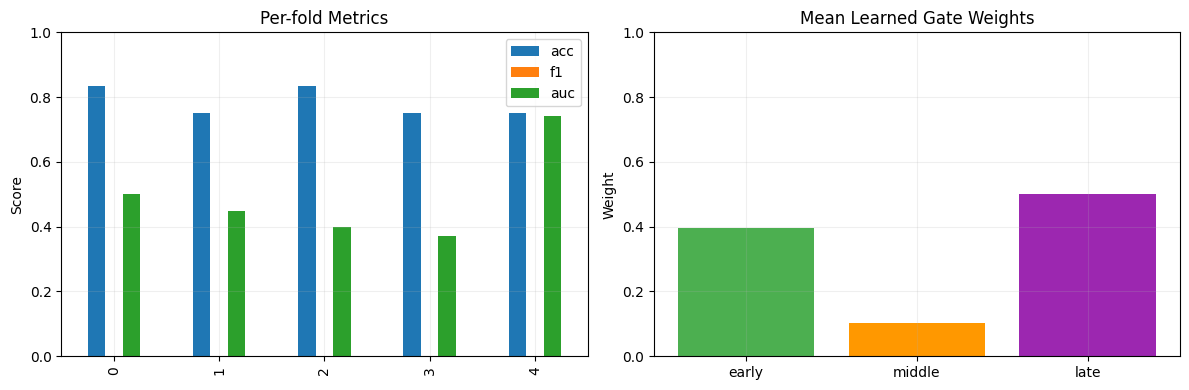

Saved plot: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/results/gating_network/gating_metrics_and_weights.png
Mean gate weights (early, middle, late): [0.3969 0.1016 0.5015]
Interpretation: higher weight means the model relied more on that segment.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary[["acc", "f1", "auc"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Per-fold Metrics")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.0)
axes[0].grid(alpha=0.2)

mean_gates = summary[["gate_early", "gate_middle", "gate_late"]].mean().values
axes[1].bar(["early", "middle", "late"], mean_gates, color=["#4CAF50", "#FF9800", "#9C27B0"])
axes[1].set_title("Mean Learned Gate Weights")
axes[1].set_ylabel("Weight")
axes[1].set_ylim(0, 1.0)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plot_path = OUT_DIR / "gating_metrics_and_weights.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print("Saved plot:", plot_path)
print("Mean gate weights (early, middle, late):", np.round(mean_gates, 4))
print("Interpretation: higher weight means the model relied more on that segment.")

## 10. Save, Reload, and Run Inference

In [13]:
# Train a final model on all data for save/reload demo.
final_loader = DataLoader(data, batch_size=CFG["batch_size"], shuffle=True, collate_fn=collator)
final_model = Wav2Vec2TemporalGatedClassifier(backbone, backbone.config.hidden_size).to(DEVICE)
final_optimizer = make_optimizer(final_model)

for epoch in range(1, 4):
    losses = []
    for batch in final_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = train_step(final_model, batch, final_optimizer)
        losses.append(out["loss"])
    print(f"Final model epoch {epoch}: loss={np.mean(losses):.4f}")

ckpt_dir = OUT_DIR / "checkpoint"
ckpt_dir.mkdir(parents=True, exist_ok=True)
state_path = ckpt_dir / "gating_model.pt"
proc_dir = ckpt_dir / "processor"

torch.save(final_model.state_dict(), state_path)
processor.save_pretrained(proc_dir)
print("Saved model:", state_path)
print("Saved processor:", proc_dir)

# Reload and compare output on one batch.
reloaded_processor = Wav2Vec2Processor.from_pretrained(proc_dir)
_ = reloaded_processor  # object existence check
reloaded_model = Wav2Vec2TemporalGatedClassifier(backbone, backbone.config.hidden_size).to(DEVICE)
reloaded_model.load_state_dict(torch.load(state_path, map_location=DEVICE))
reloaded_model.eval()
final_model.eval()

demo_batch = next(iter(final_loader))
demo_batch = {k: v.to(DEVICE) for k, v in demo_batch.items()}
with torch.no_grad():
    before = torch.softmax(final_model(demo_batch), dim=-1)[:, 1]
    after = torch.softmax(reloaded_model(demo_batch), dim=-1)[:, 1]

max_abs_diff = torch.max(torch.abs(before - after)).item()
print("Inference consistency max |diff|:", max_abs_diff)
print("Sample PD probabilities:", after[:5].detach().cpu().numpy())

Final model epoch 1: loss=0.5215
Final model epoch 2: loss=0.4716
Final model epoch 3: loss=0.3980
Saved model: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/results/gating_network/checkpoint/gating_model.pt
Saved processor: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/results/gating_network/checkpoint/processor
Inference consistency max |diff|: 0.0
Sample PD probabilities: [0.35181105 0.14739175 0.41413268 0.13177848 0.28309265]
